# Classificação de Dígitos Manuscritos com Machine Learning

## Objetivo

Desenvolver e comparar modelos de classificação capazes de reconhecer dígitos manuscritos do dataset **MNIST**. A análise considera o desempenho preditivo, o custo computacional e a robustez dos modelos em diferentes cenários.

## Etapas de desenvolvimento

### 1. Carregamento e análise exploratória dos dados

- Carregar o dataset MNIST.
- Verificar o formato dos dados, as classes e a quantidade de amostras.
- Avaliar o balanceamento entre as classes.
- Visualizar exemplos dos dígitos.

### 2. Preparação dos dados

- Separar os dados em conjuntos de treino, validação e teste.
- Manter a proporção das classes durante a divisão.
- Normalizar os valores dos pixels para o intervalo entre 0 e 1.

### 3. Treinamento dos modelos

Treinar e comparar os seguintes modelos:

- Random Forest;
- KNN;
- SVM
- Rede Neural MLP.

Também serão definidos e ajustados hiperparâmetros para buscar melhores resultados.

### 4. Avaliação dos modelos

Comparar os modelos utilizando:

- Acurácia;
- Precisão;
- Recall;
- F1-Score;
- Matrizes de confusão;
- Tempo de treinamento.

### 5. Teste de robustez

- Verificar o comportamento dos modelos quando determinados dígitos não aparecem no treinamento.
- Testar o modelo selecionado com imagens de dígitos escritos à mão.
- Processar as imagens externas utilizando OpenCV.

## Resultado esperado

Ao final, selecionar o modelo com o melhor equilíbrio entre desempenho, tempo de treinamento e capacidade de generalização.

Fase 1: Carregamento e Análise Exploratória de Dados (EDA)

Nesta fase conhecemos os dados antes de treinar os modelos. Cada imagem do MNIST possui 28 × 28 pixels, totalizando 784 valores quando é transformada em vetor para os modelos. Cada pixel é um número entre 0 (preto) e 255 (branco). Também verificamos se há exemplos de todos os dígitos e se as classes estão equilibradas.

In [37]:
from google.colab import drive

drive.mount('/content/drive')
%cd /content/drive/MyDrive/Modulo-02-MniProjeto

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Modulo-02-MniProjeto


In [38]:
%pip install -r requirements.txt

Dataset baixado com sucesso!

=== DIMENSIONALIDADE DOS MATRIZES ===
Matriz de Características (X): (70000, 784) (Imagens x Pixels)
Matriz de Rótulos (y): (70000,)



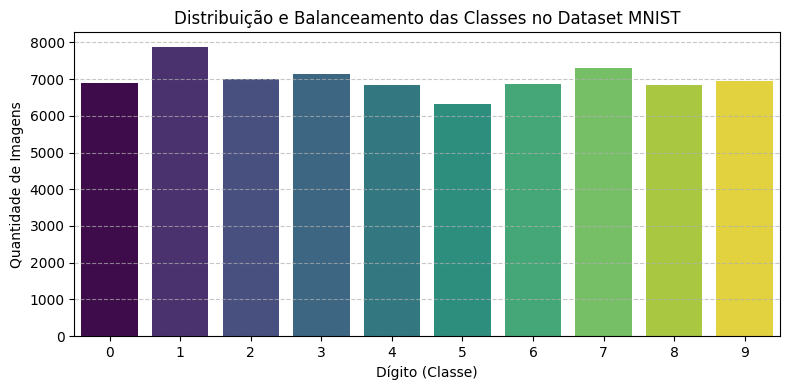

=== GRADE VISUAL: EXEMPLOS DE DÍGITOS ===


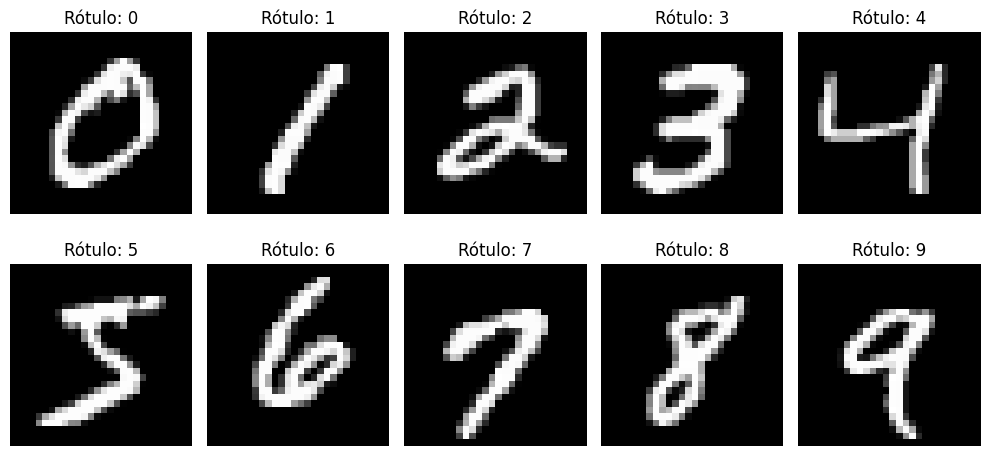

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import time
from pathlib import Path
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch
import tensorflow as tf
from tensorflow import keras


pasta_graficos = Path('outputs') / 'graficos'
pasta_graficos.mkdir(parents=True, exist_ok=True)

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto',
    data_home='./data'
 )

print("Dataset baixado com sucesso!")

# Separando recursos (X) e rótulos (y)
X, y = mnist["data"], mnist["target"]
y = y.astype(np.uint8)

# 1. EXIBIR DIMENSIONALIDADE
print("\n=== DIMENSIONALIDADE DOS MATRIZES ===")
print(f"Matriz de Características (X): {X.shape} (Imagens x Pixels)")
print(f"Matriz de Rótulos (y): {y.shape}\n")

# 2. COMPROVAR O BALANCEAMENTO DAS CLASSES
classes, contagens = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 4))
sns.barplot(
    x=classes,
    y=contagens,
    hue=classes,
    palette="viridis",
    legend=False
)
plt.title("Distribuição e Balanceamento das Classes no Dataset MNIST")
plt.xlabel("Dígito (Classe)")
plt.ylabel("Quantidade de Imagens")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(pasta_graficos / '1 = distribuicao_classes.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. GERAR GRADE VISUAL (Mínimo 2x5)
print("=== GRADE VISUAL: EXEMPLOS DE DÍGITOS ===")
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i in range(10):
    indice = np.where(y == i)
    imagem_digito = X[indice][0].reshape(28, 28)
    axes[i].imshow(imagem_digito, cmap="gray")
    axes[i].set_title(f"Rótulo: {i}", fontsize=12)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(pasta_graficos / '2 = exemplos_digitos.png', dpi=300, bbox_inches='tight')
plt.show()

Fase 2: Preparação dos Dados

A normalização dos pixels para a escala [0, 1] é fundamental para algoritimos de Machine Learning porque garante que todos os recursos (features) tenham o mesmo peso inicial. Para modelos lineares e baseados em distâncias métricas, dados não normalizados causam instabilidade no gradiente, fazendo com que o modelo demore muito mais para convergir (encontrar o resultado ideal) ou at´e mesmo falhe em convergir.

In [40]:
# Normalizando os valores dos pixels para o intervalo [0, 1]
x_scaled = X / 255.0  

X_train_val, X_test, y_train_val, y_test = train_test_split(
    x_scaled, 
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, 
    y_train_val,
    test_size=0.125,
    stratify=y_train_val,
    random_state=42
)

display("\n=== DIVISÃO DO DATASET ===")
display(f"Treinamento: {X_train.shape[0]} amostras")
display(f"Validação: {X_val.shape[0]} amostras")
display(f"Teste: {X_test.shape[0]} amostras")

'\n=== DIVISÃO DO DATASET ==='

'Treinamento: 49000 amostras'

'Validação: 7000 amostras'

'Teste: 14000 amostras'

Fase 3: Treinamento dos Modelos

Nesta fase treinamos modelos diferentes para descobrir qual deles reconhece melhor os dígitos. Cada modelo aprende de uma forma: a Random Forest usa várias árvores de decisão, o KNN procura imagens parecidas, o SVM separa as classes e a MLP aprende padrões por meio de neurônios artificiais.

1 = MODELO RANDOM FOREST

Foram usados `n_estimators=100` para combinar 100 árvores e reduzir a variação das previsões, e `max_depth=10` para limitar a complexidade e o tempo de treinamento.

In [41]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

tempo_inicio_rf = time.perf_counter()
modelo_rf.fit(X_train, y_train)
tempo_treinamento_rf = time.perf_counter() - tempo_inicio_rf

predicoes_rf = modelo_rf.predict(X_test)

report_dict = classification_report(y_test, predicoes_rf, output_dict=True)

df_metrics = pd.DataFrame(report_dict).transpose()

df_metrics.round(4)

,precision,recall,f1-score,support
0,0.9624,0.9833,0.9728,1381.0000
1,0.9643,0.9771,0.9707,1575.0000
2,0.9479,0.9363,0.9421,1398.0000
3,0.9385,0.9300,0.9342,1428.0000
4,0.9528,0.9326,0.9426,1365.0000
5,0.9579,0.9192,0.9382,1263.0000
6,0.9557,0.9731,0.9643,1375.0000
7,0.9488,0.9404,0.9446,1459.0000
8,0.9251,0.9231,0.9241,1365.0000
9,0.8904,0.9224,0.9061,1391.0000


2 = MODELO KNN

O KNN usa `n_neighbors=5`, equilibrando sensibilidade a ruído e decisão local, e `weights='distance'`, dando maior importância aos vizinhos mais próximos.

In [42]:
modelo_knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

tempo_inicio_knn = time.perf_counter()
modelo_knn.fit(X_train, y_train)
tempo_treinamento_knn = time.perf_counter() - tempo_inicio_knn

predicoes_knn = modelo_knn.predict(X_test)

report_dict_knn = classification_report(y_test, predicoes_knn, output_dict=True)

df_metrics_knn = pd.DataFrame(report_dict_knn).transpose()

df_metrics_knn.round(4)

,precision,recall,f1-score,support
0,0.9745,0.9949,0.9846,1381.0000
1,0.9543,0.9937,0.9736,1575.0000
2,0.9889,0.9528,0.9705,1398.0000
3,0.9706,0.9727,0.9717,1428.0000
4,0.9864,0.9568,0.9714,1365.0000
5,0.9613,0.9628,0.9620,1263.0000
6,0.9741,0.9862,0.9801,1375.0000
7,0.9634,0.9753,0.9693,1459.0000
8,0.9869,0.9377,0.9617,1365.0000
9,0.9485,0.9662,0.9573,1391.0000


3 = MODELO SVM

O kernel `rbf` permite fronteiras não lineares; `C=1.0` equilibra margem e erros de treino; e `gamma='scale'` ajusta a influência de cada amostra à escala dos dados.

### Perfil de execução: local ou Colab

Use `AMBIENTE = "local"` para desenvolver no computador e `AMBIENTE = "colab"` para a execução final completa. O SVM RBF cresce muito em custo com o número de imagens. No perfil local ele treina uma amostra estratificada de 12 mil imagens; no Colab usa todo o conjunto de treino. O teste permanece idêntico nos dois perfis, mas a comparação de tempo deve sempre registrar qual perfil foi usado.


In [43]:
# Altere somente esta variável conforme o ambiente.
AMBIENTE = "colab"  # opções: "local" ou "colab"
AMOSTRAS_SVM_LOCAL = 25_000

if AMBIENTE not in {"local", "colab"}:
    raise ValueError("AMBIENTE deve ser 'local' ou 'colab'.")

if AMBIENTE == "local":
    X_train_svm, _, y_train_svm, _ = train_test_split(
        X_train, y_train, train_size=AMOSTRAS_SVM_LOCAL,
        stratify=y_train, random_state=42
    )
    print(f"Perfil local: SVM treinado com {len(y_train_svm):,} amostras.")
else:
    X_train_svm, y_train_svm = X_train, y_train
    print(f"Perfil Colab: SVM treinado com {len(y_train_svm):,} amostras.")


Perfil Colab: SVM treinado com 49,000 amostras.


In [44]:
modelo_svm = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    # probability=True executa uma calibração interna cara. Use-a só no resultado final.
    probability=(AMBIENTE == "colab"),
    cache_size=2048,
    random_state=42
)

tempo_inicio_svm = time.perf_counter()
modelo_svm.fit(X_train_svm, y_train_svm)
tempo_treinamento_svm = time.perf_counter() - tempo_inicio_svm

predicoes_svm = modelo_svm.predict(X_test)

report_dict_svm = classification_report(y_test, predicoes_svm, output_dict=True)
df_metrics_svm = pd.DataFrame(report_dict_svm).transpose()

print(f"Perfil usado no SVM: {AMBIENTE}")
df_metrics_svm.round(4)


Perfil usado no SVM: colab


,precision,recall,f1-score,support
0,0.9786,0.9949,0.9867,1381.0000
1,0.9848,0.9886,0.9867,1575.0000
2,0.9764,0.9785,0.9775,1398.0000
3,0.9774,0.9685,0.9729,1428.0000
4,0.9750,0.9714,0.9732,1365.0000
5,0.9808,0.9723,0.9765,1263.0000
6,0.9833,0.9847,0.9840,1375.0000
7,0.9754,0.9767,0.9760,1459.0000
8,0.9744,0.9751,0.9747,1365.0000
9,0.9675,0.9619,0.9647,1391.0000


4 = REDE NEURAL PERCEPTRON

A MLP possui uma camada oculta com 100 neurônios e ativação ReLU para aprender padrões não lineares. O otimizador Adam e `max_iter=200` oferecem uma convergência eficiente com limite de iterações.

In [45]:
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42
)

tempo_inicio_mlp = time.perf_counter()
modelo_mlp.fit(X_train, y_train)
tempo_treinamento_mlp = time.perf_counter() - tempo_inicio_mlp

predicoes_mlp = modelo_mlp.predict(X_test)

report_dict_mlp = classification_report(y_test, predicoes_mlp, output_dict=True)

df_metrics_mlp = pd.DataFrame(report_dict_mlp).transpose()

df_metrics_mlp.round(4)

,precision,recall,f1-score,support
0,0.9779,0.9949,0.9864,1381.0000
1,0.9836,0.9892,0.9864,1575.0000
2,0.9806,0.9764,0.9785,1398.0000
3,0.9781,0.9713,0.9747,1428.0000
4,0.9744,0.9744,0.9744,1365.0000
5,0.9730,0.9715,0.9723,1263.0000
6,0.9891,0.9855,0.9872,1375.0000
7,0.9714,0.9760,0.9737,1459.0000
8,0.9777,0.9641,0.9709,1365.0000
9,0.9627,0.9641,0.9634,1391.0000


## 5 = REDE NEURAL COM KERAS

A quinta etapa usa uma rede neural profunda em TensorFlow/Keras para comparar com a MLP do scikit-learn. A arquitetura foi escolhida para manter a mesma ideia da MLP anterior: entrada com 784 pixels, camadas densas com ReLU e saída com 10 classes. A diferença principal é que a implementação em Keras permite treinar a rede com maior controle de otimização, batch e validação durante o treinamento.

Com o mesmo conjunto de treino e teste dos modelos anteriores, esta comparação ajuda a responder qual abordagem oferece o melhor balanço entre desempenho e custo computacional.

In [46]:
try:
    import tensorflow as tf
    from tensorflow import keras
    print('TensorFlow já disponível:', tf.__version__)
except ModuleNotFoundError:
    import subprocess, sys
    print('TensorFlow não encontrado. Instalando no ambiente do projeto...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow-cpu==2.16.2'])
    import tensorflow as tf
    from tensorflow import keras
    print('TensorFlow instalado com sucesso:', tf.__version__)


TensorFlow já disponível: 2.20.0


Fase 4: Avaliação dos Modelos

Nesta fase comparamos os resultados dos modelos usando dados de teste, que não foram usados no treinamento. A acurácia mostra a quantidade total de acertos; precisão, recall e F1-score ajudam a entender a qualidade das previsões em cada classe. As matrizes de confusão mostram quais dígitos o modelo mais confunde.

In [47]:
modelo_keras = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

modelo_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

tempo_inicio_keras = time.perf_counter()
hist_keras = modelo_keras.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    verbose=0
)
tempo_treinamento_keras = time.perf_counter() - tempo_inicio_keras

predicoes_keras = modelo_keras.predict(X_test, verbose=0)
predicoes_keras = predicoes_keras.argmax(axis=1)

report_dict_keras = classification_report(y_test, predicoes_keras, output_dict=True)
df_metrics_keras = pd.DataFrame(report_dict_keras).transpose()

print(f"Rede Keras treinada com {X_train.shape[0]} amostras no mesmo split dos outros modelos.")
df_metrics_keras.round(4)

Rede Keras treinada com 49000 amostras no mesmo split dos outros modelos.


,precision,recall,f1-score,support
0,0.9800,0.9949,0.9874,1381.0000
1,0.9873,0.9892,0.9883,1575.0000
2,0.9787,0.9843,0.9815,1398.0000
3,0.9845,0.9783,0.9814,1428.0000
4,0.9800,0.9700,0.9750,1365.0000
5,0.9817,0.9794,0.9806,1263.0000
6,0.9840,0.9869,0.9855,1375.0000
7,0.9834,0.9767,0.9801,1459.0000
8,0.9780,0.9773,0.9776,1365.0000
9,0.9720,0.9727,0.9723,1391.0000


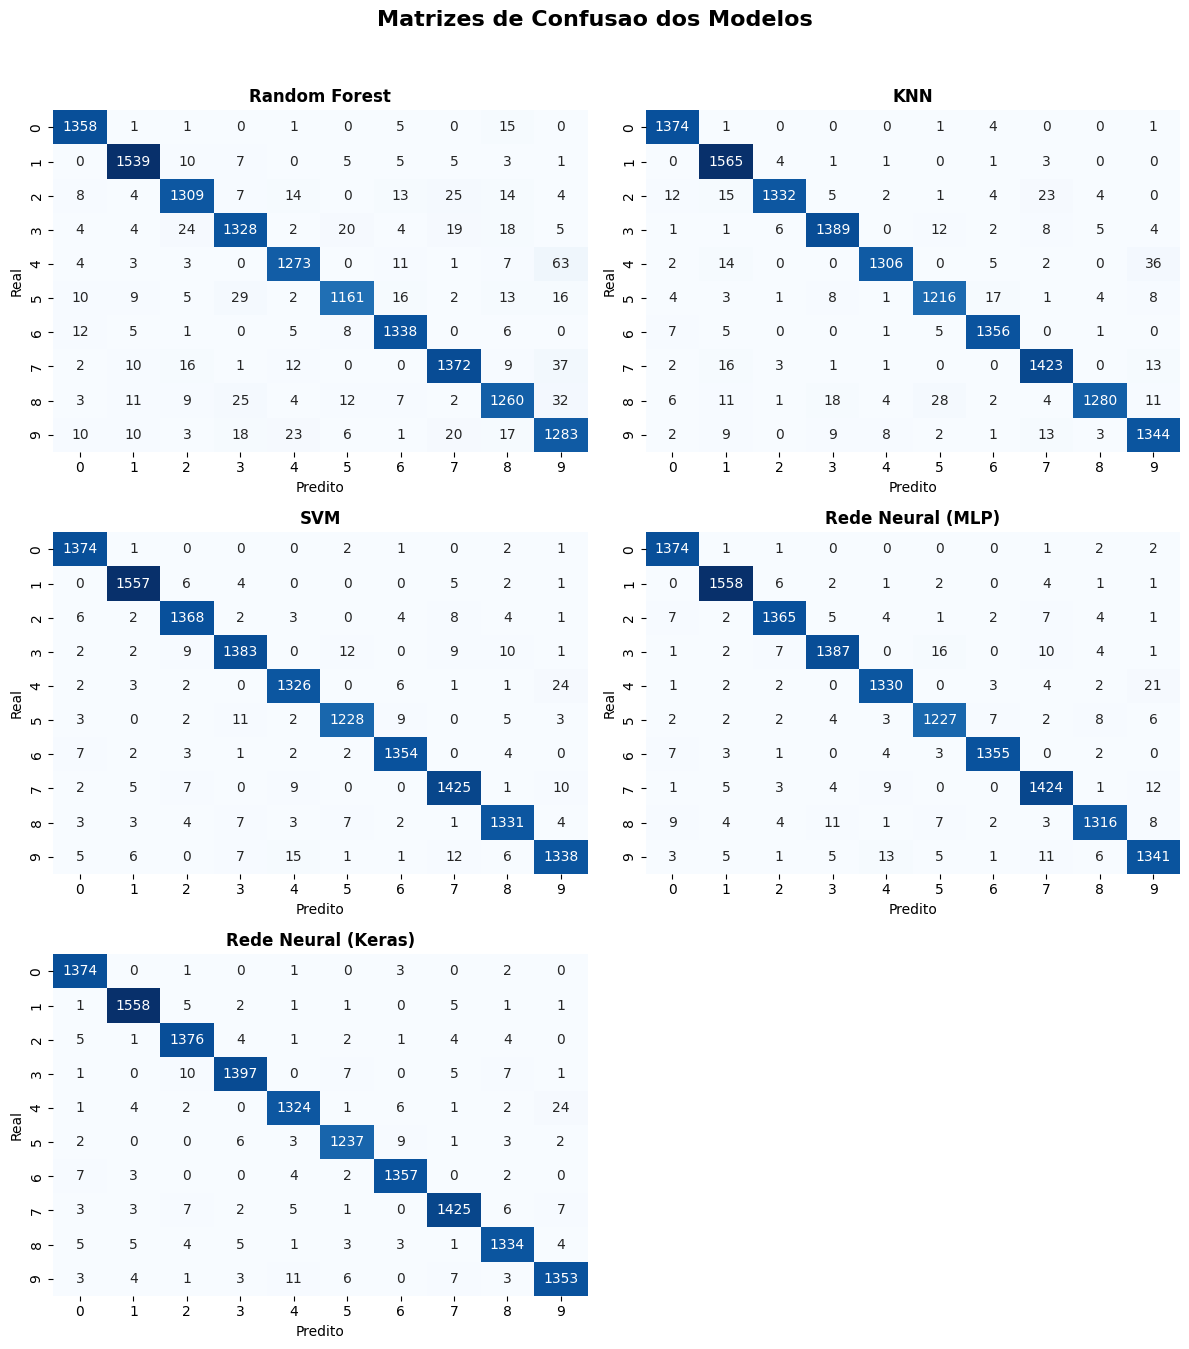

In [48]:
modelos_nomes = ['Random Forest', 'KNN', 'SVM', 'Rede Neural (MLP)', 'Rede Neural (Keras)']
predicoes = [predicoes_rf, predicoes_knn, predicoes_svm, predicoes_mlp, predicoes_keras]

fig, eixos = plt.subplots(3, 2, figsize=(12, 14))
eixos_flat = eixos.ravel()

for eixo, nome, pred in zip(eixos_flat, modelos_nomes, predicoes):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=list(range(10)), yticklabels=list(range(10)), ax=eixo)
    eixo.set_title(nome, fontsize=12, fontweight='bold')
    eixo.set_xlabel('Predito')
    eixo.set_ylabel('Real')

for eixo in eixos_flat[len(modelos_nomes):]:
    eixo.axis('off')

fig.suptitle('Matrizes de Confusao dos Modelos', fontsize=16, fontweight='bold')
fig.tight_layout(rect=[0, 0.02, 1, 0.96])
fig.savefig(pasta_graficos / '3 = matrizes_confusao_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

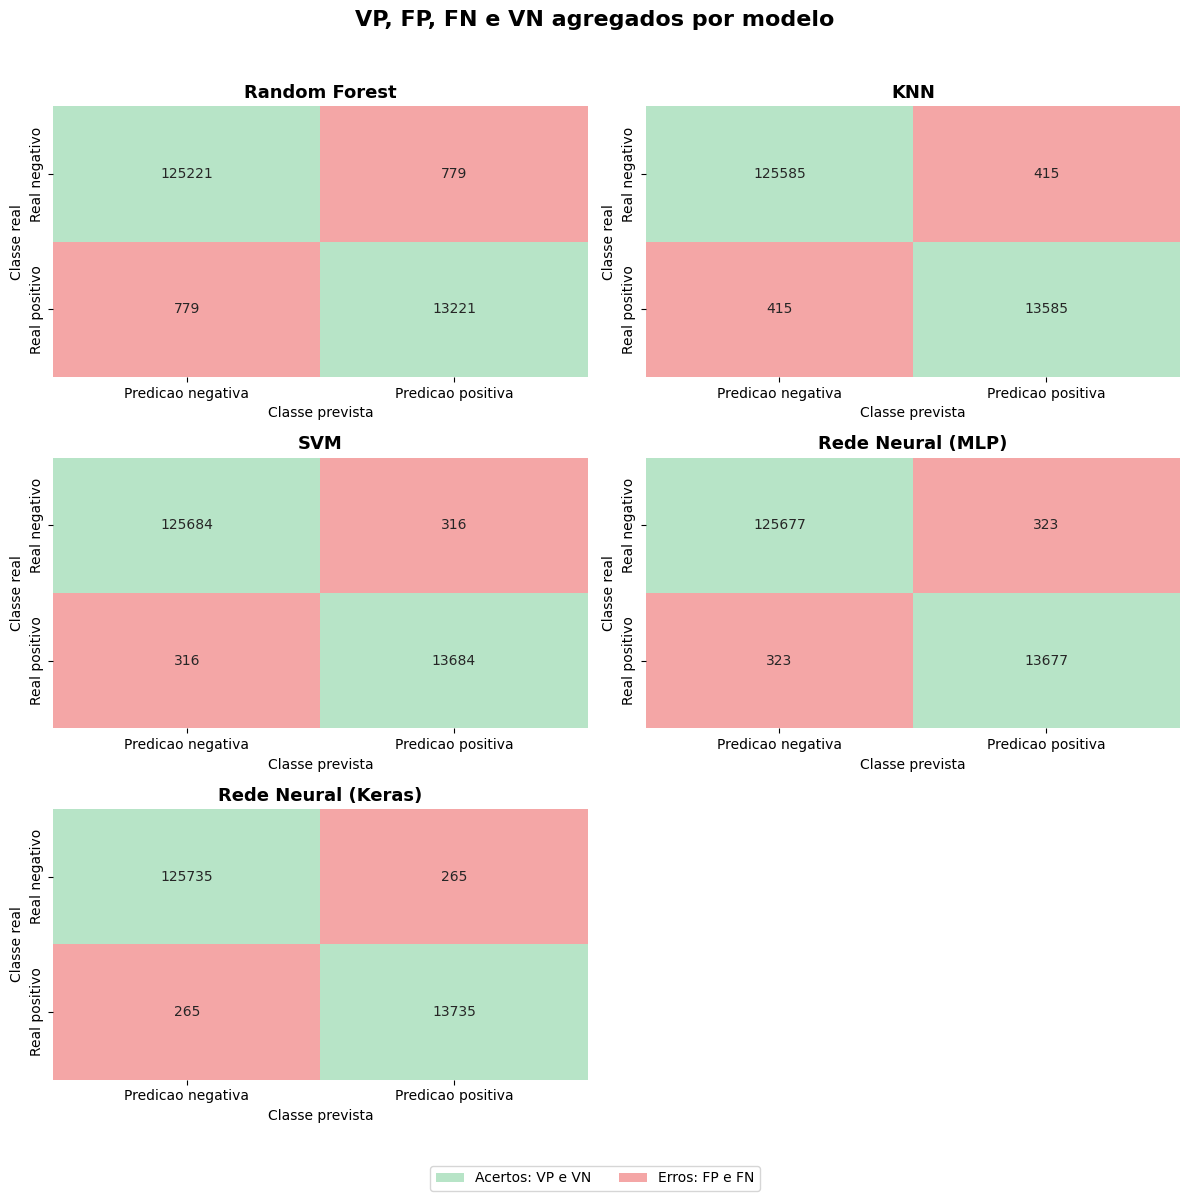

,Modelo,Verdadeiros positivos (VP),Falsos positivos (FP),Falsos negativos (FN),Verdadeiros negativos (VN)
0,Random Forest,13221,779,779,125221
1,KNN,13585,415,415,125585
2,SVM,13684,316,316,125684
3,Rede Neural (MLP),13677,323,323,125677
4,Rede Neural (Keras),13735,265,265,125735


In [49]:
resultados_tp_fp_fn_tn = []
fig, eixos = plt.subplots(3, 2, figsize=(12, 12))
eixos_flat = eixos.ravel()

for eixo, nome, pred in zip(eixos_flat, modelos_nomes, predicoes):
    matriz = confusion_matrix(y_test, pred)
    verdadeiros_positivos = falsos_positivos = falsos_negativos = verdadeiros_negativos = 0
    for indice_classe in range(len(classes)):
        verdadeiros_positivos += matriz[indice_classe, indice_classe]
        falsos_positivos += matriz[:, indice_classe].sum() - matriz[indice_classe, indice_classe]
        falsos_negativos += matriz[indice_classe, :].sum() - matriz[indice_classe, indice_classe]
        verdadeiros_negativos += (matriz.sum() - matriz[indice_classe, :].sum()
                                  - matriz[:, indice_classe].sum()
                                  + matriz[indice_classe, indice_classe])

    matriz_binaria = np.array([[verdadeiros_negativos, falsos_positivos],
                               [falsos_negativos, verdadeiros_positivos]])
    matriz_cores = np.array([[0, 1], [1, 0]])
    sns.heatmap(matriz_binaria, annot=True, fmt='d',
                cmap=ListedColormap(['#b7e4c7', '#f4a6a6']),
                norm=BoundaryNorm([-0.5, 0.5, 1.5], 2), cbar=False,
                xticklabels=['Predicao negativa', 'Predicao positiva'],
                yticklabels=['Real negativo', 'Real positivo'], ax=eixo)
    eixo.collections[-1].set_array(matriz_cores.ravel())
    eixo.set_title(nome, fontsize=13, fontweight='bold')
    eixo.set_xlabel('Classe prevista')
    eixo.set_ylabel('Classe real')
    resultados_tp_fp_fn_tn.append({'Modelo': nome,
        'Verdadeiros positivos (VP)': verdadeiros_positivos,
        'Falsos positivos (FP)': falsos_positivos,
        'Falsos negativos (FN)': falsos_negativos,
        'Verdadeiros negativos (VN)': verdadeiros_negativos})

for eixo in eixos_flat[len(modelos_nomes):]:
    eixo.axis('off')

fig.suptitle('VP, FP, FN e VN agregados por modelo', fontsize=16, fontweight='bold')
fig.legend(handles=[Patch(facecolor='#b7e4c7', label='Acertos: VP e VN'),
                    Patch(facecolor='#f4a6a6', label='Erros: FP e FN')],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=[0, 0.04, 1, 0.96])
fig.savefig(pasta_graficos / '4 = vp_fp_fn_vn_modelos.png', dpi=300, bbox_inches='tight')
plt.show()
df_tp_fp_fn_tn = pd.DataFrame(resultados_tp_fp_fn_tn)
display(df_tp_fp_fn_tn)

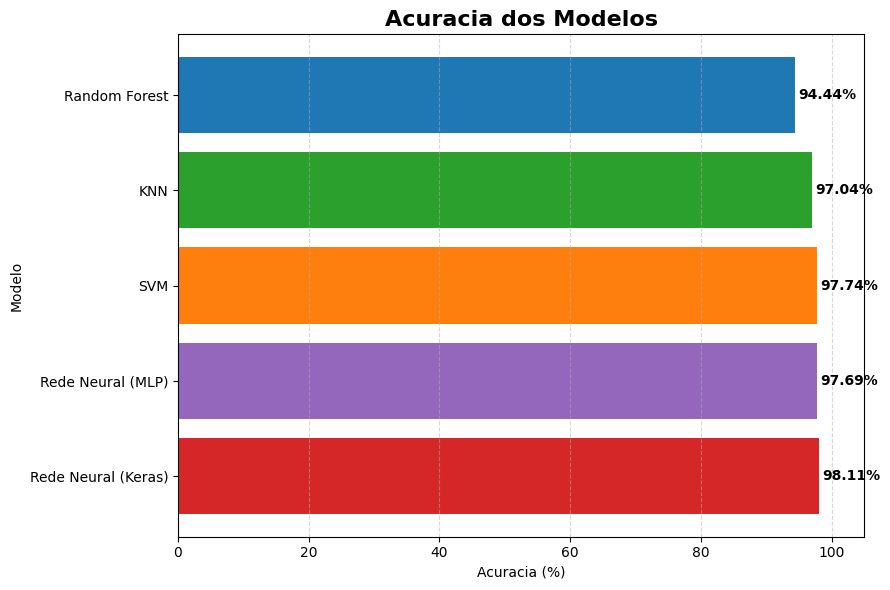

In [50]:
modelos_nomes = ['Random Forest', 'KNN', 'SVM', 'Rede Neural (MLP)', 'Rede Neural (Keras)']
acuracias = [np.mean(y_test == pred) * 100 for pred in predicoes]
fig, eixo = plt.subplots(figsize=(9, 6))
barras = eixo.barh(modelos_nomes, acuracias,
                   color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#d62728'])
eixo.set_title('Acuracia dos Modelos', fontsize=16, fontweight='bold')
eixo.set_xlabel('Acuracia (%)')
eixo.set_ylabel('Modelo')
eixo.set_xlim(0, 105)
eixo.grid(axis='x', linestyle='--', alpha=0.5)
eixo.invert_yaxis()
for barra, acuracia in zip(barras, acuracias):
    eixo.text(acuracia + 0.5, barra.get_y() + barra.get_height() / 2,
              f'{acuracia:.2f}%', va='center', fontweight='bold')
fig.tight_layout()
fig.savefig(pasta_graficos / '5 = acuracia_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

,Modelo,Tempo de treinamento (s)
0,Random Forest,22.81
1,KNN,0.03
2,SVM,794.10
3,Rede Neural (MLP),63.87
4,Rede Neural (Keras),444.18


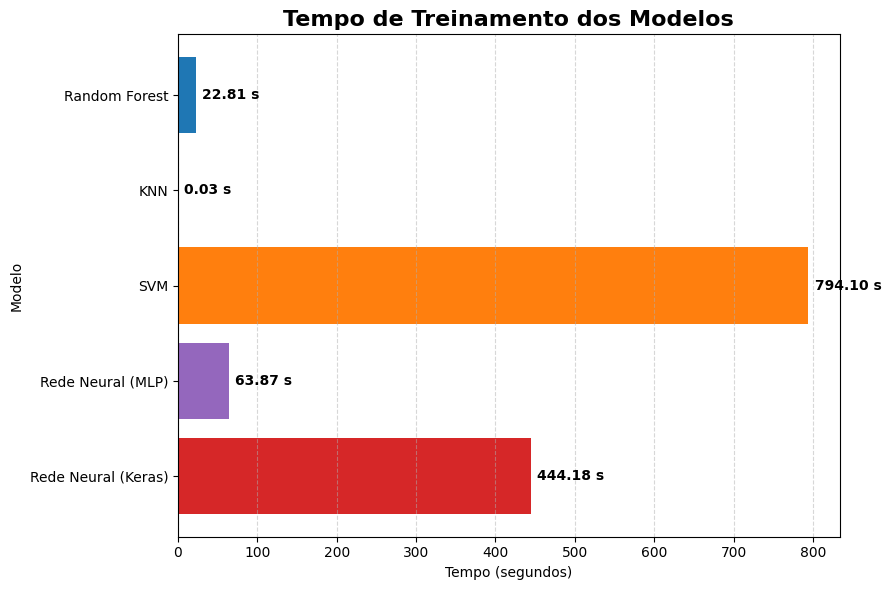

In [51]:
modelos_nomes = ['Random Forest', 'KNN', 'SVM', 'Rede Neural (MLP)', 'Rede Neural (Keras)']
tempos_treinamento = [tempo_treinamento_rf, tempo_treinamento_knn,
                      tempo_treinamento_svm, tempo_treinamento_mlp, tempo_treinamento_keras]
df_tempos = pd.DataFrame({'Modelo': modelos_nomes,
                           'Tempo de treinamento (s)': tempos_treinamento})
display(df_tempos.round(2))
fig, eixo = plt.subplots(figsize=(9, 6))
barras = eixo.barh(modelos_nomes, tempos_treinamento,
                   color=['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#d62728'])
eixo.set_title('Tempo de Treinamento dos Modelos', fontsize=16, fontweight='bold')
eixo.set_xlabel('Tempo (segundos)')
eixo.set_ylabel('Modelo')
eixo.grid(axis='x', linestyle='--', alpha=0.5)
eixo.invert_yaxis()
for barra, tempo in zip(barras, tempos_treinamento):
    eixo.text(tempo + max(tempos_treinamento) * 0.01,
              barra.get_y() + barra.get_height() / 2,
              f'{tempo:.2f} s', va='center', fontweight='bold')
fig.tight_layout()
fig.savefig(pasta_graficos / '6 = tempo_treinamento_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

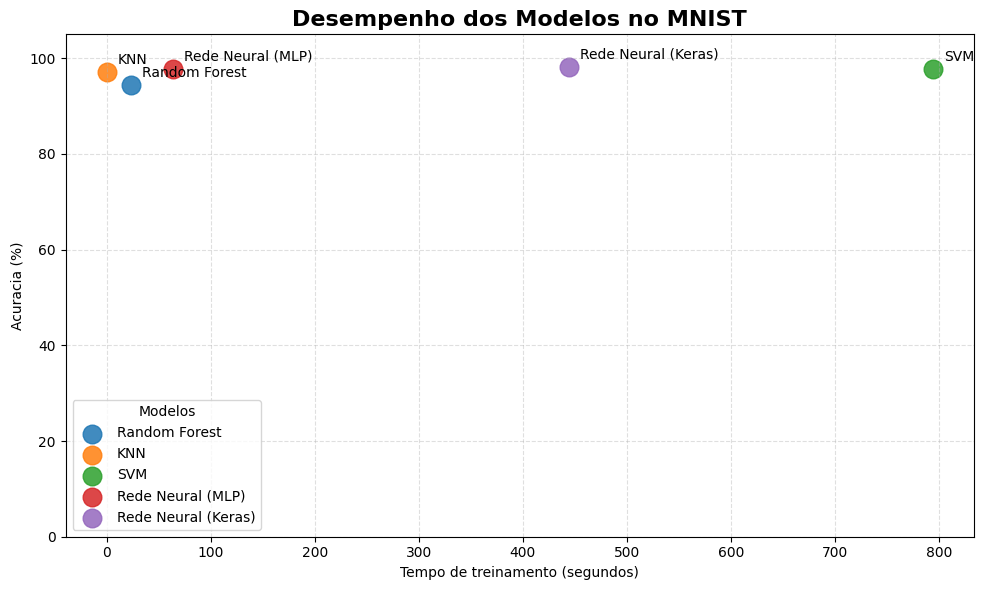

,Modelo,Acuracia (%),Tempo de treinamento (s)
4,Rede Neural (Keras),98.11,444.18
2,SVM,97.74,794.10
3,Rede Neural (MLP),97.69,63.87
1,KNN,97.04,0.03
0,Random Forest,94.44,22.81


,Modelo,Acurácia (%),Precisão ponderada,Recall ponderado,F1-score ponderado,Tempo de treinamento (s)
4,Rede Neural (Keras),98.1071,0.9811,0.9811,0.9811,444.1760
2,SVM,97.7429,0.9774,0.9774,0.9774,794.0967
3,Rede Neural (MLP),97.6929,0.9769,0.9769,0.9769,63.8651
1,KNN,97.0357,0.9707,0.9704,0.9703,0.0321
0,Random Forest,94.4357,0.9445,0.9444,0.9443,22.8058


Melhor desempenho: Rede Neural (Keras) (98.11% de acurácia).
As matrizes de confusão mostram quais pares de dígitos geram mais erros; o tempo de treinamento ajuda a avaliar o custo desse ganho de acurácia.


In [52]:
acuracias = [np.mean(y_test == pred) * 100 for pred in predicoes]
df_desempenho = pd.DataFrame({'Modelo': modelos_nomes,
                              'Acuracia (%)': acuracias,
                              'Tempo de treinamento (s)': tempos_treinamento})
fig, eixo = plt.subplots(figsize=(10, 6))
for _, linha in df_desempenho.iterrows():
    eixo.scatter(linha['Tempo de treinamento (s)'], linha['Acuracia (%)'],
                 s=180, alpha=0.85, label=linha['Modelo'])
    eixo.annotate(linha['Modelo'],
                  (linha['Tempo de treinamento (s)'], linha['Acuracia (%)']),
                  xytext=(8, 6), textcoords='offset points')
eixo.set_title('Desempenho dos Modelos no MNIST', fontsize=16, fontweight='bold')
eixo.set_xlabel('Tempo de treinamento (segundos)')
eixo.set_ylabel('Acuracia (%)')
eixo.set_ylim(0, 105)
eixo.grid(True, linestyle='--', alpha=0.4)
eixo.legend(title='Modelos')
fig.tight_layout()
fig.savefig(pasta_graficos / '7 = desempenho_modelos.png', dpi=300, bbox_inches='tight')
plt.show()
display(df_desempenho.sort_values('Acuracia (%)', ascending=False).round(2))

# Tabela consolidada exigida para a comparação dos modelos
relatorios = [report_dict, report_dict_knn, report_dict_svm, report_dict_mlp, report_dict_keras]
modelos_treinados = [modelo_rf, modelo_knn, modelo_svm, modelo_mlp, modelo_keras]
resultados_completos = []
for nome, pred, tempo, relatorio in zip(modelos_nomes, predicoes, tempos_treinamento, relatorios):
    resultados_completos.append({
        'Modelo': nome,
        'Acurácia (%)': np.mean(y_test == pred) * 100,
        'Precisão ponderada': relatorio['weighted avg']['precision'],
        'Recall ponderado': relatorio['weighted avg']['recall'],
        'F1-score ponderado': relatorio['weighted avg']['f1-score'],
        'Tempo de treinamento (s)': tempo
    })

df_resultados_completos = pd.DataFrame(resultados_completos)
display(df_resultados_completos.sort_values('Acurácia (%)', ascending=False).round(4))

melhor_indice = int(np.argmax(acuracias))
melhor_modelo = modelos_treinados[melhor_indice]
melhor_nome = modelos_nomes[melhor_indice]
print(f'Melhor desempenho: {melhor_nome} ({acuracias[melhor_indice]:.2f}% de acurácia).')
print('As matrizes de confusão mostram quais pares de dígitos geram mais erros; o tempo de treinamento ajuda a avaliar o custo desse ganho de acurácia.')

Fase 5: Robustez do Modelo e Predição com Imagens Próprias

Nesta fase testamos situações mais próximas do mundo real. Primeiro, retiramos alguns dígitos do treinamento para observar como o modelo reage a algo que nunca viu. Depois, testamos uma imagem manuscrita própria, preparando-a para ficar parecida com as imagens do MNIST: em tons de cinza, centralizada, com tamanho 28 × 28 e valores normalizados entre 0 e 1.

Fase 5.1 - Treinamento com Classes Ocultas

In [53]:
# Usa a divisão estratificada e os dados normalizados criados na Fase 2.
classes_ocultas = np.array([4, 7])
mascara_treino = ~np.isin(y_train, classes_ocultas)
X_train_restrito = X_train[mascara_treino]
y_train_restrito = y_train[mascara_treino]

print("[Fase 5.1] Treinando sem os dígitos 4 e 7...")
print(f"Classes presentes no treino: {np.unique(y_train_restrito)}")

modelo_restrito = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
modelo_restrito.fit(X_train_restrito, y_train_restrito)
print("Modelo restrito treinado com sucesso.")

[Fase 5.1] Treinando sem os dígitos 4 e 7...
Classes presentes no treino: [0 1 2 3 5 6 8 9]
Modelo restrito treinado com sucesso.


Fase 5.2 - Comportamento diante de Classes Não Vistas

In [54]:
if 'modelo_restrito' not in globals():
    raise RuntimeError("Execute a célula da Fase 5.1 antes desta.")

# Código de predição OOD: use somente as imagens das classes ocultas.
mascara_teste_ood = np.isin(y_test, classes_ocultas)
X_test_ood = X_test[mascara_teste_ood]
y_test_ood = y_test[mascara_teste_ood]
predicoes_ood = modelo_restrito.predict(X_test_ood)

classes_conhecidas, contagens = np.unique(predicoes_ood, return_counts=True)
print(f"Amostras OOD avaliadas: {len(y_test_ood)}")
print("Classes previstas pelo modelo:", classes_conhecidas)


Amostras OOD avaliadas: 2824
Classes previstas pelo modelo: [0 1 2 3 5 6 8 9]


#### Como interpretar as predições das classes ocultas

Os dígitos 4 e 7 foram retirados do treinamento. Portanto, o classificador não possui essas duas opções e é obrigado a atribuir cada imagem a uma das classes que conhece. O gráfico abaixo resume para quais classes conhecidas essas imagens foram direcionadas; não representa acertos de 4 ou 7.


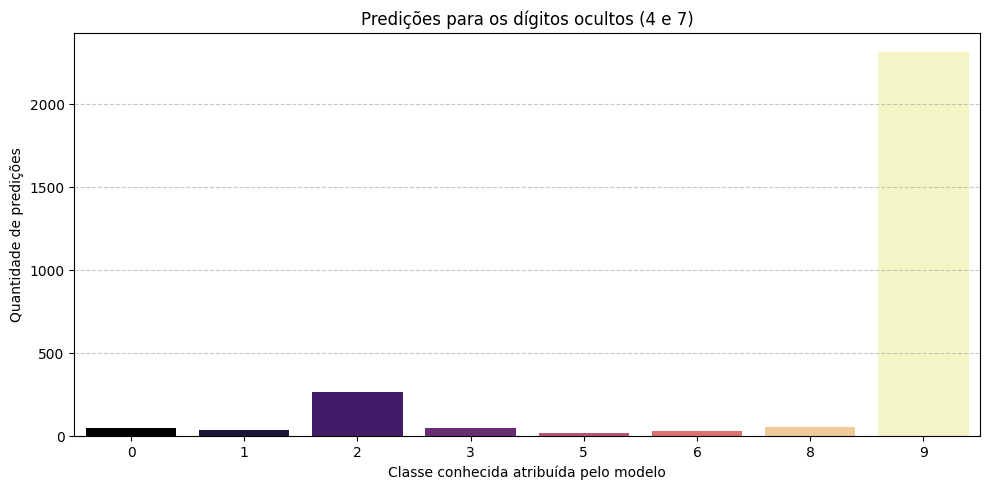

In [55]:
# Gráfico separado: distribuição das classes atribuídas às imagens OOD.
plt.figure(figsize=(10, 5))
sns.barplot(x=classes_conhecidas, y=contagens, hue=classes_conhecidas,
            palette="magma", legend=False)
plt.title("Predições para os dígitos ocultos (4 e 7)")
plt.xlabel("Classe conhecida atribuída pelo modelo")
plt.ylabel("Quantidade de predições")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(pasta_graficos / '8 = predicoes_classes_ocultas.png', dpi=300, bbox_inches='tight')
plt.show()


#### Matriz de confusão OOD

Nesta matriz, as linhas são as classes reais e as colunas são as classes previstas. Apenas as linhas 4 e 7 terão valores, pois o conjunto OOD contém somente esses dígitos. Como 4 e 7 não existem no treinamento, suas colunas ficam zeradas: a matriz evidencia a `falsa certeza` de um classificador fechado, que sempre escolhe alguma classe conhecida.


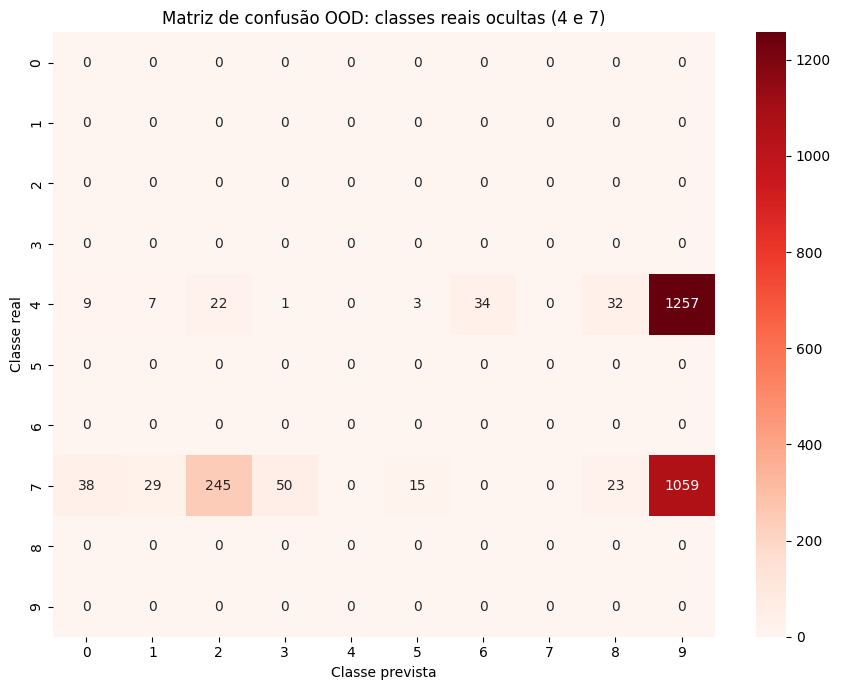

In [56]:
# Gráfico separado: matriz de confusão exclusiva do cenário OOD.
rotulos_ood = list(range(10))
matriz_ood = confusion_matrix(y_test_ood, predicoes_ood, labels=rotulos_ood)

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_ood, annot=True, fmt='d', cmap='Reds',
            xticklabels=rotulos_ood, yticklabels=rotulos_ood)
plt.title('Matriz de confusão OOD: classes reais ocultas (4 e 7)')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.tight_layout()
plt.savefig(pasta_graficos / '9 = matriz_confusao_ood.png', dpi=300, bbox_inches='tight')
plt.show()


Fase 5.3 - Predição com Imagem Manuscrita Própria

In [57]:
# ==========================================
# 1. FUNÇÃO DE PRÉ-PROCESSAMENTO
# ==========================================
def preprocessar_imagem(caminho_imagem, inverter_cores=False):
    img = cv2.imread(str(caminho_imagem), cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Não foi possível ler a imagem no caminho: {caminho_imagem}")

    # Na maior parte dos rascunhos, o papel é claro e o algoritmo é escuro.
    # O MNIST usa fundo claro e dígito escuro, então manter esse padrão evita
    # distorcer o contorno do dígito ao inverter a imagem inteira.
    if inverter_cores:
        img = cv2.bitwise_not(img)

    img = cv2.GaussianBlur(img, (5, 5), 0)
    _, img_thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contornos, _ = cv2.findContours(img_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contornos:
        contornos_filtrados = [c for c in contornos if cv2.contourArea(c) > 50]
        if contornos_filtrados:
            maior_contorno = max(contornos_filtrados, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(maior_contorno)
            padding = 8
            x = max(0, x - padding)
            y = max(0, y - padding)
            w = min(img.shape[1] - x, w + 2 * padding)
            h = min(img.shape[0] - y, h + 2 * padding)
            recorte = img_thresh[y:y + h, x:x + w]

            escala = 20 / max(w, h)
            novo_tamanho = (max(1, round(w * escala)), max(1, round(h * escala)))
            digito = cv2.resize(recorte, novo_tamanho, interpolation=cv2.INTER_AREA)

            # Centraliza o dígito em uma imagem 28x28, como o MNIST.
            img_28x28 = np.zeros((28, 28), dtype=np.uint8)
            inicio_y = (28 - digito.shape[0]) // 2
            inicio_x = (28 - digito.shape[1]) // 2
            img_28x28[inicio_y:inicio_y + digito.shape[0],
                      inicio_x:inicio_x + digito.shape[1]] = digito
        else:
            img_28x28 = cv2.resize(img_thresh, (28, 28), interpolation=cv2.INTER_AREA)
    else:
        img_28x28 = cv2.resize(img_thresh, (28, 28), interpolation=cv2.INTER_AREA)

    # Mantém o padrão do MNIST: fundo branco e traço escuro.
    return img_28x28.astype('float32') / 255.0


# ==========================================
# 2. DIRETÓRIOS E SELEÇÃO AUTOMÁTICA
# ==========================================
pasta_imagens = Path.cwd() / "imagem"
arquivos_imagem = sorted(
    list(pasta_imagens.glob("*.jpeg")) + list(pasta_imagens.glob("*.jpg"))
)

if not arquivos_imagem:
    raise FileNotFoundError(
        f"Nenhuma imagem .jpeg ou .jpg encontrada em: {pasta_imagens}"
    )

caminho_imagem = arquivos_imagem[0]
print(f"📸 Imagem encontrada e selecionada: {caminho_imagem.name}")


# ==========================================
# 3. MELHOR MODELO SELECIONADO NA FASE 4
# ==========================================
if 'melhor_modelo' not in globals():
    raise RuntimeError("Execute a Fase 4 antes desta célula para selecionar o melhor modelo.")


📸 Imagem encontrada e selecionada: WhatsApp Image 2026-09-07 at 10.06.37.jpeg


In [60]:
# Código de predição: prepara a imagem e consulta o modelo selecionado.
# A imagem do caderno tem fundo claro e traço escuro; manter esse padrão é
# fundamental para que a forma do dígito fique próxima do MNIST.
img_pronta = preprocessar_imagem(caminho_imagem, inverter_cores=False)
entrada_modelo = img_pronta.reshape(1, -1)

saida_modelo = melhor_modelo.predict(entrada_modelo)

if isinstance(saida_modelo, np.ndarray) and saida_modelo.ndim == 2 and saida_modelo.shape[1] == 10:
    probabilidades = saida_modelo[0]
    predicao = int(np.argmax(probabilidades))
elif isinstance(saida_modelo, np.ndarray) and saida_modelo.ndim == 1 and saida_modelo.size == 10:
    probabilidades = saida_modelo
    predicao = int(np.argmax(probabilidades))
else:
    predicao = int(saida_modelo[0])
    probabilidades = None

if probabilidades is None:
    if hasattr(melhor_modelo, 'predict_proba'):
        probabilidades = melhor_modelo.predict_proba(entrada_modelo)[0]
        titulo_saida = 'Probabilidades de saída'
    elif hasattr(melhor_modelo, 'decision_function'):
        # No perfil local, o SVM não é calibrado para reduzir o tempo de treino.
        escores = melhor_modelo.decision_function(entrada_modelo)[0]
        probabilidades = np.exp(escores - np.max(escores))
        probabilidades /= probabilidades.sum()
        titulo_saida = 'Escores normalizados (SVM sem calibração)'
    elif hasattr(melhor_modelo, 'predict'):
        saida = melhor_modelo.predict(entrada_modelo)
        if isinstance(saida, np.ndarray) and saida.ndim == 2 and saida.shape[1] == 10:
            probabilidades = saida[0]
            titulo_saida = 'Probabilidades de saída (Keras)'
        else:
            probabilidades = np.zeros(10, dtype=float)
            probabilidades[predicao] = 1.0
            titulo_saida = 'Previsão de classe'
    else:
        probabilidades = np.zeros(10, dtype=float)
        probabilidades[predicao] = 1.0
        titulo_saida = 'Previsão de classe'
else:
    titulo_saida = 'Probabilidades de saída'

print(f"Melhor modelo selecionado: {melhor_nome}")

print(f"Dígito previsto: {predicao}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Melhor modelo selecionado: Rede Neural (Keras)
Dígito previsto: 4


#### Resultado da predição da imagem própria

À esquerda está a imagem depois do pré-processamento para o padrão MNIST (28 × 28 pixels). À direita aparecem as probabilidades do modelo; quando o melhor modelo for o SVM no perfil local, o gráfico mostra escores normalizados, pois as probabilidades calibradas foram desativadas para acelerar o treino.


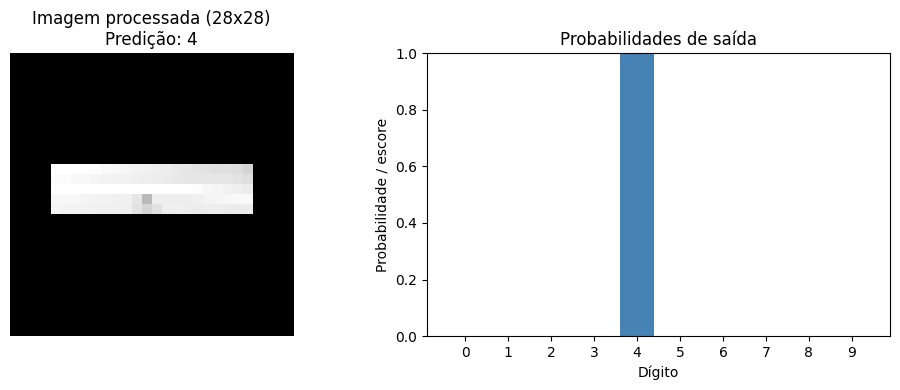

In [61]:
# Gráfico separado: apresentação do resultado da predição.
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
eixos[0].imshow(img_pronta, cmap='gray')
eixos[0].set_title(f"Imagem processada (28x28)\nPredição: {predicao}")
eixos[0].axis('off')

eixos[1].bar(range(10), probabilidades, color='steelblue')
eixos[1].set_title(titulo_saida)
eixos[1].set_xlabel('Dígito')
eixos[1].set_ylabel('Probabilidade / escore')
eixos[1].set_xticks(range(10))
eixos[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(pasta_graficos / '10 = predicao_imagem_propria.png', dpi=300, bbox_inches='tight')
plt.show()
